In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv("cubic_zirconia.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z,price
0,1,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,2,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,3,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,4,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,5,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [4]:
#dropping unnamed as it is not useful for model
df=df.drop("Unnamed: 0",axis=1)

In [5]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,Ideal,E,SI1,62.1,58.0,4.27,4.29,2.66,499
1,0.33,Premium,G,IF,60.8,58.0,4.42,4.46,2.70,984
2,0.90,Very Good,E,VVS2,62.2,60.0,6.04,6.12,3.78,6289
3,0.42,Ideal,F,VS1,61.6,56.0,4.82,4.80,2.96,1082
4,0.31,Ideal,F,VVS1,60.4,59.0,4.35,4.43,2.65,779


In [6]:
df.shape

(26967, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26967 entries, 0 to 26966
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    26967 non-null  float64
 1   cut      26967 non-null  object 
 2   color    26967 non-null  object 
 3   clarity  26967 non-null  object 
 4   depth    26270 non-null  float64
 5   table    26967 non-null  float64
 6   x        26967 non-null  float64
 7   y        26967 non-null  float64
 8   z        26967 non-null  float64
 9   price    26967 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 2.1+ MB


In [8]:
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

In [9]:
#checking duplicates
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 34


In [10]:
print("Before",df.shape)
df.drop_duplicates(inplace=True)
print("After",df.shape)

Before (26967, 10)
After (26933, 10)


In [11]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [12]:
df.isnull().sum()

carat        0
cut          0
color        0
clarity      0
depth      697
table        0
x            0
y            0
z            0
price        0
dtype: int64

In [13]:
df.describe(include="all")

,carat,cut,color,clarity,depth,table,x,y,z,price
count,26933.000000,26933,26933,26933,26236.000000,26933.000000,26933.000000,26933.000000,26933.000000,26933.000000
unique,NaN,5,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,10805,5653,6565,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.798010,NaN,NaN,NaN,61.745285,57.455950,5.729346,5.733102,3.537769,3937.526120
std,0.477237,NaN,NaN,NaN,1.412243,2.232156,1.127367,1.165037,0.719964,4022.551862
min,0.200000,NaN,NaN,NaN,50.800000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,4.710000,4.710000,2.900000,945.000000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,5.690000,5.700000,3.520000,2375.000000
75%,1.050000,NaN,NaN,NaN,62.500000,59.000000,6.550000,6.540000,4.040000,5356.000000


In [14]:
#unique values for categorical variables
for column in df.columns:
    if df[column].dtype=="object":
        print(column.upper(),':',df[column].nunique())
        print (df[column].value_counts().sort_values())
        print('\n')

CUT : 5
Fair           780
Good          2435
Very Good     6027
Premium       6886
Ideal        10805
Name: cut, dtype: int64


COLOR : 7
J    1440
I    2765
D    3341
H    4095
F    4723
E    4916
G    5653
Name: color, dtype: int64


CLARITY : 8
I1       364
IF       891
VVS1    1839
VVS2    2530
VS1     4087
SI2     4564
VS2     6093
SI1     6565
Name: clarity, dtype: int64




In [14]:
#imputing missing values with median
for column in df.columns:
    if df[column].dtype != "object":
        median=df[column].median()
        df[column]=df[column].fillna(median)
        
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26933 entries, 0 to 26966
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    26933 non-null  float64
 1   cut      26933 non-null  object 
 2   color    26933 non-null  object 
 3   clarity  26933 non-null  object 
 4   depth    26933 non-null  float64
 5   table    26933 non-null  float64
 6   x        26933 non-null  float64
 7   y        26933 non-null  float64
 8   z        26933 non-null  float64
 9   price    26933 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 2.3+ MB


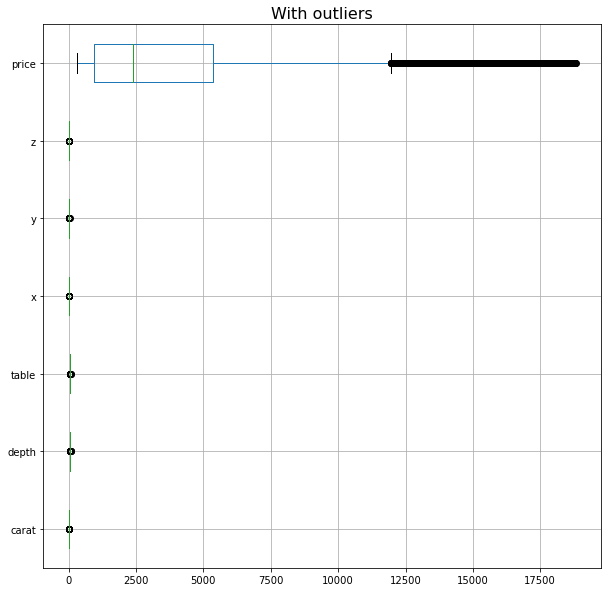

In [16]:
#boxplots for continuous variable
cols = ["carat","depth","table","x","y","z","price"]
plt.figure(figsize=(10,10))
df[cols].boxplot(vert=0)
plt.title("With outliers",fontsize=16)
plt.show()

In [17]:
#treating outliers
def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range=Q1-(1.5*IQR)
    upper_range=Q3+(1.5*IQR)
    return lower_range, upper_range

In [18]:
for column in df.columns:
    if df[column].dtype != "object":
        lr,ur = remove_outlier(df[column])
        df[column]=np.where(df[column]>ur,ur,df[column])
        df[column]=np.where(df[column]<lr,lr,df[column])

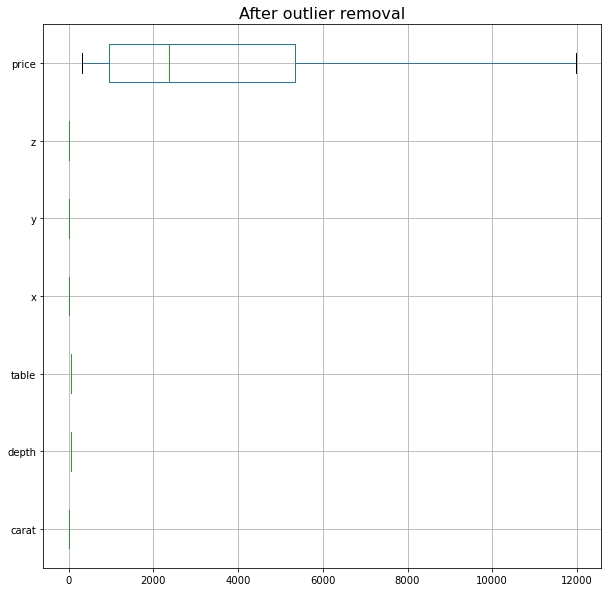

In [19]:
#boxplots after outlier treatment
plt.figure(figsize=(10,10))
df[cols].boxplot(vert=0)
plt.title("After outlier removal",fontsize=16)
plt.show()

In [22]:
#checking correlation
df.corr()

,carat,depth,table,x,y,z,price
carat,1.000000,0.029433,0.187143,0.982387,0.981464,0.977508,0.936762
depth,0.029433,1.000000,-0.289357,-0.019848,-0.022884,0.095253,-0.001060
table,0.187143,-0.289357,1.000000,0.199061,0.193428,0.159380,0.137880
x,0.982387,-0.019848,0.199061,1.000000,0.998491,0.988168,0.912933
y,0.981464,-0.022884,0.193428,0.998491,1.000000,0.987841,0.914361
z,0.977508,0.095253,0.159380,0.988168,0.987841,1.000000,0.905866
price,0.936762,-0.001060,0.137880,0.912933,0.914361,0.905866,1.000000


<AxesSubplot:>

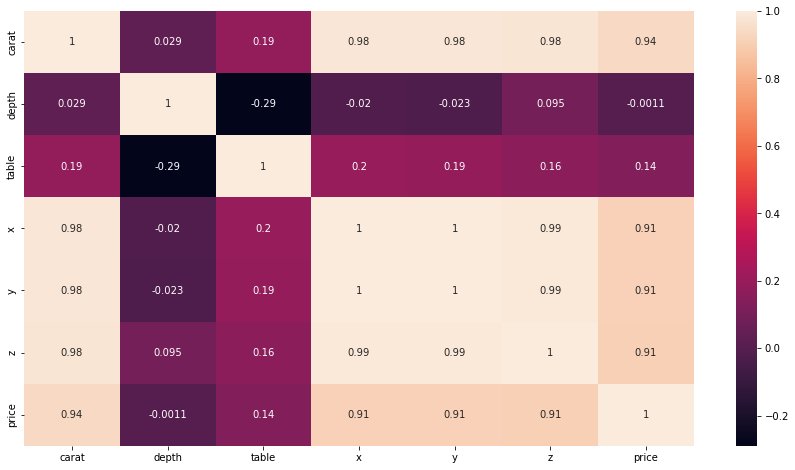

In [23]:
#correlation heatmap
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(),annot=True)

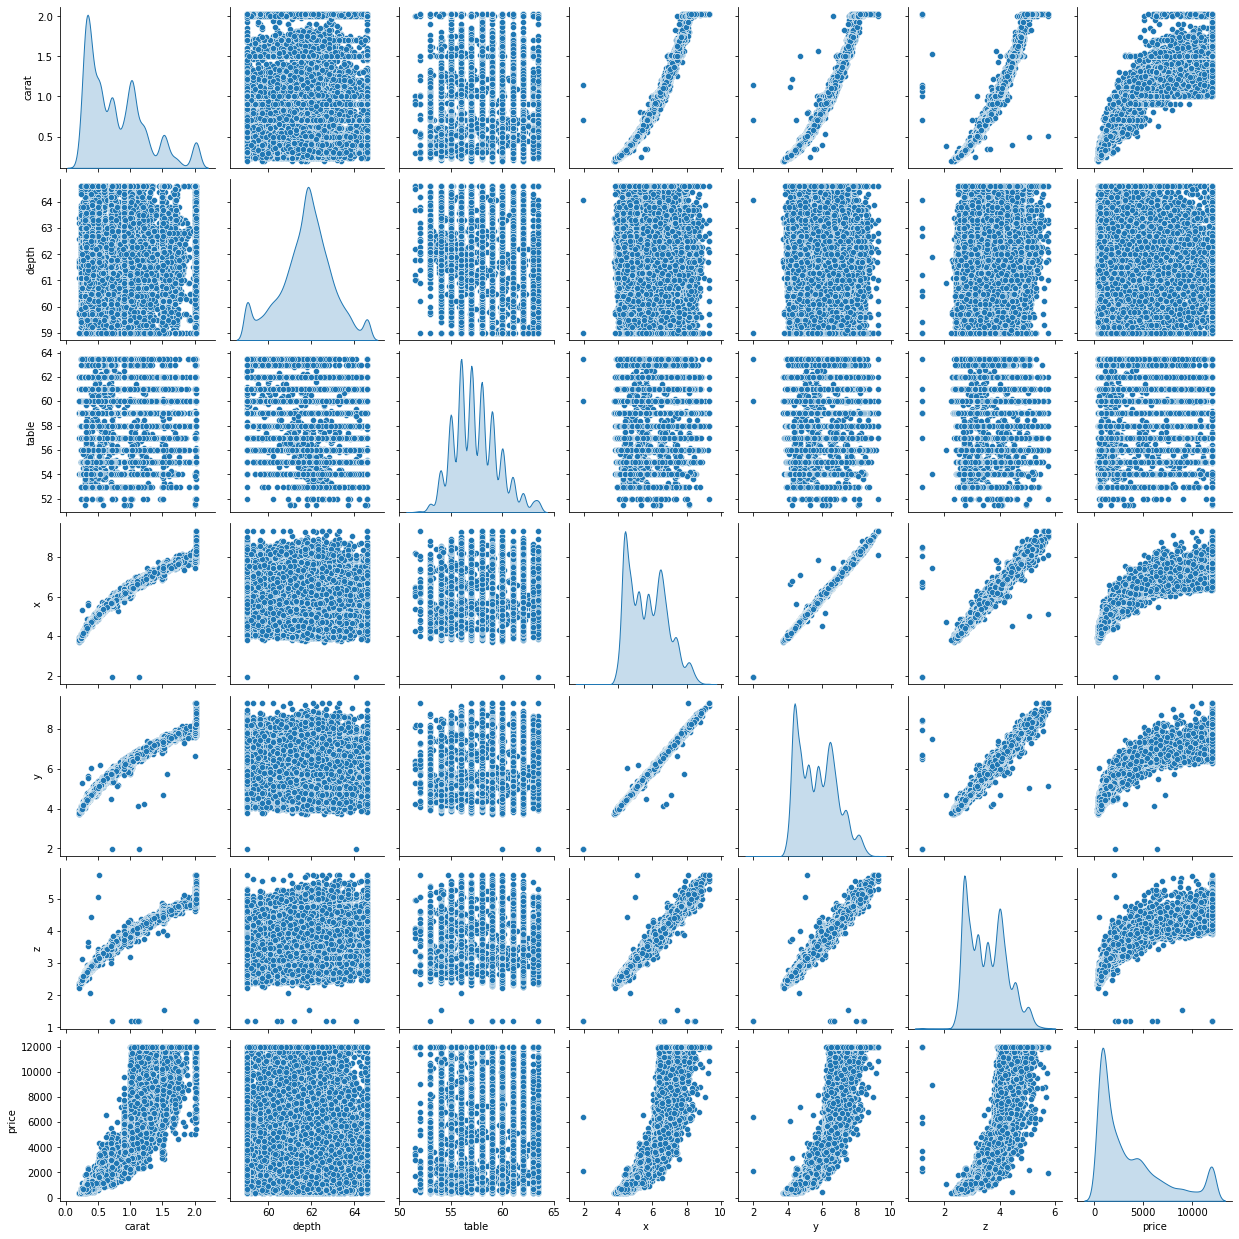

In [24]:
#pairplot
sns.pairplot(df,diag_kind='kde');

In [27]:
df[df["x"]==0]

,carat,cut,color,clarity,depth,table,x,y,z,price


In [28]:
df[df["z"]==0]

,carat,cut,color,clarity,depth,table,x,y,z,price


In [29]:
df[df["y"]==0]

,carat,cut,color,clarity,depth,table,x,y,z,price


In [59]:
# we are combining certain levels of cut under different categories
df["cut"]=np.where(df["cut"]=="Good","Good",df["cut"])
df["cut"]=np.where(df["cut"]=="Very Good","Good",df["cut"])

In [60]:
df["cut"].value_counts()

Ideal      10805
Good        8462
Premium     6886
Fair         780
Name: cut, dtype: int64

In [61]:
# we are combining certain levels of clarity under different categories
df["clarity"]=np.where(df["clarity"]=="VVS1","VVS",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VVS2","VVS",df["clarity"])

df["clarity"]=np.where(df["clarity"]=="VS1","VS",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VS2","VS",df["clarity"])

df["clarity"]=np.where(df["clarity"]=="SI1","SI",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="SI2","SI",df["clarity"])

In [62]:
df["clarity"].value_counts()

SI     11129
VS     10180
VVS     4369
IF       891
I1       364
Name: clarity, dtype: int64

In [63]:
# we are encoding the cut, color and clarity in an ordinal manner
df["cut"]=np.where(df["cut"]=="Fair","1",df["cut"])
df["cut"]=np.where(df["cut"]=="Good","2",df["cut"])
df["cut"]=np.where(df["cut"]=="Premium","3",df["cut"])
df["cut"]=np.where(df["cut"]=="Ideal","4",df["cut"])

In [21]:
df["color"]=np.where(df["color"]=="D","1",df["color"])
df["color"]=np.where(df["color"]=="E","2",df["color"])
df["color"]=np.where(df["color"]=="F","3",df["color"])
df["color"]=np.where(df["color"]=="G","4",df["color"])
df["color"]=np.where(df["color"]=="H","5",df["color"])
df["color"]=np.where(df["color"]=="I","6",df["color"])
df["color"]=np.where(df["color"]=="J","7",df["color"])

In [65]:
df["clarity"]=np.where(df["clarity"]=="IF","1",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VVS","2",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VS","3",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="SI","4",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="I1","5",df["clarity"])

In [66]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.30,4,2,4,62.1,58.0,4.27,4.29,2.66,499
1,0.33,3,4,1,60.8,58.0,4.42,4.46,2.70,984
2,0.90,2,2,2,62.2,60.0,6.04,6.12,3.78,6289
3,0.42,4,3,3,61.6,56.0,4.82,4.80,2.96,1082
4,0.31,4,3,2,60.4,59.0,4.35,4.43,2.65,779


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26933 entries, 0 to 26966
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    26933 non-null  float64
 1   cut      26933 non-null  object 
 2   color    26933 non-null  object 
 3   clarity  26933 non-null  object 
 4   depth    26933 non-null  float64
 5   table    26933 non-null  float64
 6   x        26933 non-null  float64
 7   y        26933 non-null  float64
 8   z        26933 non-null  float64
 9   price    26933 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 2.3+ MB


In [68]:
df["cut"]=df["cut"].astype("int64")
df["color"]=df["color"].astype("int64")
df["clarity"]=df["color"].astype("int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26933 entries, 0 to 26966
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    26933 non-null  float64
 1   cut      26933 non-null  int64  
 2   color    26933 non-null  int64  
 3   clarity  26933 non-null  int64  
 4   depth    26933 non-null  float64
 5   table    26933 non-null  float64
 6   x        26933 non-null  float64
 7   y        26933 non-null  float64
 8   z        26933 non-null  float64
 9   price    26933 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 2.3 MB


# with outlier and with sub-level combined

In [69]:

X=df.drop("price",axis=1)
y=df["price"]

In [70]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=1)

In [71]:
regression_model=LinearRegression()
regression_model.fit(X_train,y_train)

LinearRegression()

In [72]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 11581.016683733771
The coefficient for cut is 181.21235755877842
The coefficient for color is -135.66237812264438
The coefficient for clarity is -135.6623781226433
The coefficient for depth is -153.67557438776942
The coefficient for table is -63.74257026343272
The coefficient for x is -1484.4337011028053
The coefficient for y is 19.24013001963791
The coefficient for z is -3.532364468217622


In [73]:
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 16687.925289551575


In [74]:
#R square on training data
regression_model.score(X_train,y_train)

0.8727999769810524

In [75]:
#R square on testing data
regression_model.score(X_test,y_test)

0.87599035887169

In [76]:
#RMSE on training
predicted_train=regression_model.fit(X_train,y_train).predict(X_train)
np.sqrt(metrics.mean_squared_error(y_train,predicted_train))

1429.9775371056423

In [77]:
#RMSE on testing
predicted_test=regression_model.fit(X_train,y_train).predict(X_test)
np.sqrt(metrics.mean_squared_error(y_test,predicted_test))

1427.151809206291

In [78]:
# linear regression using stats model
data_train=pd.concat([X_train,y_train],axis=1)
data_train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
22114,0.34,2,5,5,62.4,60.0,4.41,4.44,2.76,537
2275,0.30,4,2,2,61.2,55.0,4.35,4.31,2.65,844
19183,0.50,4,4,4,62.5,57.0,5.09,5.05,3.17,1240
5030,1.10,2,2,2,63.3,56.0,6.53,6.58,4.15,4065
25414,1.02,3,3,3,61.1,62.0,6.54,6.49,3.98,4057


In [79]:
import statsmodels.formula.api as smf
lm1=smf.ols(formula="price~carat+cut+color+clarity+depth+table+x+y+z",data=data_train).fit()
lm1.params

Intercept    16687.925290
carat        11581.016684
cut            181.212358
color         -135.662378
clarity       -135.662378
depth         -153.675574
table          -63.742570
x            -1484.433701
y               19.240130
z               -3.532364
dtype: float64

In [80]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                 1.616e+04
Date:                Sun, 03 Jul 2022   Prob (F-statistic):               0.00
Time:                        22:34:46   Log-Likelihood:            -1.6373e+05
No. Observations:               18853   AIC:                         3.275e+05
Df Residuals:                   18844   BIC:                         3.275e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.669e+04    819.832     20.355      0.0

# without outlier and no sub-level combined

In [20]:
#encoding the data 
df["cut"]=np.where(df["cut"]=="Fair","1",df["cut"])
df["cut"]=np.where(df["cut"]=="Good","2",df["cut"])
df["cut"]=np.where(df["cut"]=="Very Good","3",df["cut"])
df["cut"]=np.where(df["cut"]=="Premium","4",df["cut"])
df["cut"]=np.where(df["cut"]=="Ideal","5",df["cut"])

In [22]:
df["clarity"]=np.where(df["clarity"]=="IF","1",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VVS1","2",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VVS2","3",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VS1","4",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="VS2","5",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="SI1","6",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="SI2","7",df["clarity"])
df["clarity"]=np.where(df["clarity"]=="I1","8",df["clarity"])

In [23]:
X=df.drop("price",axis=1)
y=df["price"]

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=1)

In [27]:
regression_model=LinearRegression()
regression_model.fit(X_train,y_train)

LinearRegression()

In [28]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 8829.985689983425
The coefficient for cut is 110.86409383215617
The coefficient for color is -278.00475388207354
The coefficient for clarity is -440.56098957937377
The coefficient for depth is -7.366929069916139
The coefficient for table is -12.335846538458245
The coefficient for x is -1412.5450184859153
The coefficient for y is 1247.8206514842923
The coefficient for z is -313.13928882800053


In [29]:
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 2695.3998518633825


In [30]:
#R square on training data
regression_model.score(X_train,y_train)

0.9311670171538092

In [31]:
#R square on testing data
regression_model.score(X_test,y_test)

0.9312114379489974

In [32]:
#RMSE on training
predicted_train=regression_model.fit(X_train,y_train).predict(X_train)
np.sqrt(metrics.mean_squared_error(y_train,predicted_train))

909.2452746534678

In [33]:
#RMSE on testing
predicted_test=regression_model.fit(X_train,y_train).predict(X_test)
np.sqrt(metrics.mean_squared_error(y_test,predicted_test))

911.1429333532998

In [34]:
# linear regression using stats model
data_train=pd.concat([X_train,y_train],axis=1)
data_train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
22114,0.34,3,5,5,62.4,60.0,4.41,4.44,2.76,537.0
2275,0.30,5,2,5,61.2,55.0,4.35,4.31,2.65,844.0
19183,0.50,5,4,6,62.5,57.0,5.09,5.05,3.17,1240.0
5030,1.10,2,2,7,63.3,56.0,6.53,6.58,4.15,4065.0
25414,1.02,4,3,7,61.1,62.0,6.54,6.49,3.98,4057.0


In [35]:
import statsmodels.formula.api as smf
lm1=smf.ols(formula="price~carat+cut+color+clarity+depth+table+x+y+z",data=data_train).fit()
lm1.params

Intercept       2152.720620
cut[T.2]         481.810241
cut[T.3]         606.928585
cut[T.4]         674.826092
cut[T.5]         714.699878
color[T.2]      -181.904311
color[T.3]      -256.810372
color[T.4]      -429.383407
color[T.5]      -855.990312
color[T.6]     -1323.924855
color[T.7]     -1928.046426
clarity[T.2]    -231.714816
clarity[T.3]    -246.240561
clarity[T.4]    -661.443241
clarity[T.5]    -964.086952
clarity[T.6]   -1484.103281
clarity[T.7]   -2319.558496
clarity[T.8]   -4004.019869
carat           9126.838398
depth            -14.941125
table            -18.577262
x              -1190.174237
y                837.618693
z               -164.166490
dtype: float64

In [36]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                 1.287e+04
Date:                Sun, 03 Jul 2022   Prob (F-statistic):               0.00
Time:                        22:52:47   Log-Likelihood:            -1.5386e+05
No. Observations:               18853   AIC:                         3.078e+05
Df Residuals:                   18829   BIC:                         3.080e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     2152.7206    657.170      3.276   

# without outlier and with sub-level combined

In [56]:

X=df.drop("price",axis=1)
y=df["price"]

In [24]:
from sklearn.model_selection import train_test_split

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=1)

In [59]:
regression_model=LinearRegression()
regression_model.fit(X_train,y_train)

LinearRegression()

In [61]:
for idx, col_name in enumerate(X_train.columns):
    print("The coefficient for {} is {}".format(col_name, regression_model.coef_[idx]))

The coefficient for carat is 9515.452855470348
The coefficient for cut is 185.1714003413963
The coefficient for color is -112.1478114638456
The coefficient for clarity is -112.14781146385388
The coefficient for depth is -76.01711350781625
The coefficient for table is -37.62923797937327
The coefficient for x is -2866.652959975616
The coefficient for y is 2191.4532974919716
The coefficient for z is -320.5708934410865


In [62]:
intercept = regression_model.intercept_
print("The intercept for our model is {}".format(intercept))

The intercept for our model is 8294.302886318774


In [63]:
#R square on training data
regression_model.score(X_train,y_train)

0.8950890591874703

In [64]:
#R square on testing data
regression_model.score(X_test,y_test)

0.8986087215976895

In [25]:
from sklearn import metrics

In [67]:
#RMSE on training
predicted_train=regression_model.fit(X_train,y_train).predict(X_train)
np.sqrt(metrics.mean_squared_error(y_train,predicted_train))

1122.5175729553246

In [68]:
#RMSE on testing
predicted_test=regression_model.fit(X_train,y_train).predict(X_test)
np.sqrt(metrics.mean_squared_error(y_test,predicted_test))

1106.1873689164906

In [69]:
# linear regression using stats model
data_train=pd.concat([X_train,y_train],axis=1)
data_train.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
22114,0.34,2,5,5,62.4,60.0,4.41,4.44,2.76,537.0
2275,0.30,4,2,2,61.2,55.0,4.35,4.31,2.65,844.0
19183,0.50,4,4,4,62.5,57.0,5.09,5.05,3.17,1240.0
5030,1.10,2,2,2,63.3,56.0,6.53,6.58,4.15,4065.0
25414,1.02,3,3,3,61.1,62.0,6.54,6.49,3.98,4057.0


In [70]:
data_train.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price'],
      dtype='object')

In [71]:
import statsmodels.formula.api as smf
lm1=smf.ols(formula="price~carat+cut+color+clarity+depth+table+x+y+z",data=data_train).fit()
lm1.params

Intercept    8294.302886
carat        9515.452855
cut           185.171400
color        -112.147811
clarity      -112.147811
depth         -76.017114
table         -37.629238
x           -2866.652960
y            2191.453297
z            -320.570893
dtype: float64

In [72]:
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                 2.010e+04
Date:                Sun, 03 Jul 2022   Prob (F-statistic):               0.00
Time:                        10:08:12   Log-Likelihood:            -1.5916e+05
No. Observations:               18853   AIC:                         3.183e+05
Df Residuals:                   18844   BIC:                         3.184e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8294.3029    851.670      9.739      0.0

#### the overall p value is less than alpha (0.05) so rejecting null hypothesis and accepting alternate hypothesis that atleast 1 regression coefficient is not 0. here all regression coefficients are not 0

In [88]:
#mse
mse=np.mean((regression_model.predict(X_test)-y_test)**2)

In [89]:
#RMSE on testing
np.sqrt(mse)

1106.1873689164922

In [90]:
y_pred=regression_model.predict(X_test)

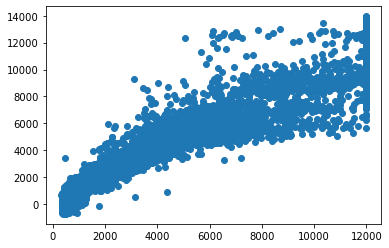

In [92]:
plt.scatter(data_test["price"],y_pred)

In [4]:
holiday=pd.read_csv("Holiday_Package.csv")

In [5]:
holiday.head()

,Unnamed: 0,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,1,no,48412,30,8,1,1,no
1,2,yes,37207,45,8,0,1,no
2,3,no,58022,46,9,0,0,no
3,4,no,66503,31,11,2,0,no
4,5,no,66734,44,12,0,2,no


In [6]:
holiday=holiday.drop("Unnamed: 0",axis=1)

In [7]:
holiday.shape

(872, 7)

In [8]:
holiday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Holliday_Package   872 non-null    object
 1   Salary             872 non-null    int64 
 2   age                872 non-null    int64 
 3   educ               872 non-null    int64 
 4   no_young_children  872 non-null    int64 
 5   no_older_children  872 non-null    int64 
 6   foreign            872 non-null    object
dtypes: int64(5), object(2)
memory usage: 47.8+ KB


In [9]:
holiday.isnull().sum()

Holliday_Package     0
Salary               0
age                  0
educ                 0
no_young_children    0
no_older_children    0
foreign              0
dtype: int64

In [10]:
holiday.dtypes


Holliday_Package     object
Salary                int64
age                   int64
educ                  int64
no_young_children     int64
no_older_children     int64
foreign              object
dtype: object

In [11]:
dups = holiday.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [12]:
holiday.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Holliday_Package,872,2,no,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,872.0,NaN,NaN,NaN,47729.172018,23418.668531,1322.0,35324.0,41903.5,53469.5,236961.0
age,872.0,NaN,NaN,NaN,39.955275,10.551675,20.0,32.0,39.0,48.0,62.0
educ,872.0,NaN,NaN,NaN,9.307339,3.036259,1.0,8.0,9.0,12.0,21.0
no_young_children,872.0,NaN,NaN,NaN,0.311927,0.61287,0.0,0.0,0.0,0.0,3.0
no_older_children,872.0,NaN,NaN,NaN,0.982798,1.086786,0.0,0.0,1.0,2.0,6.0
foreign,872,2,no,656,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
holiday.groupby(["Holliday_Package"]).count()

,Salary,age,educ,no_young_children,no_older_children,foreign
Holliday_Package,,,,,,
no,471,471,471,471,471,471
yes,401,401,401,401,401,401


C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Holliday_Package', ylabel='count'>

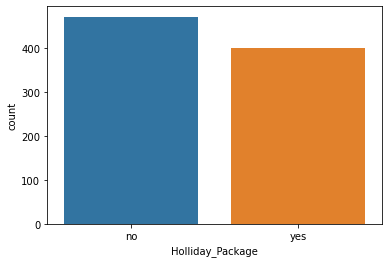

In [14]:
sns.countplot(holiday.Holliday_Package)


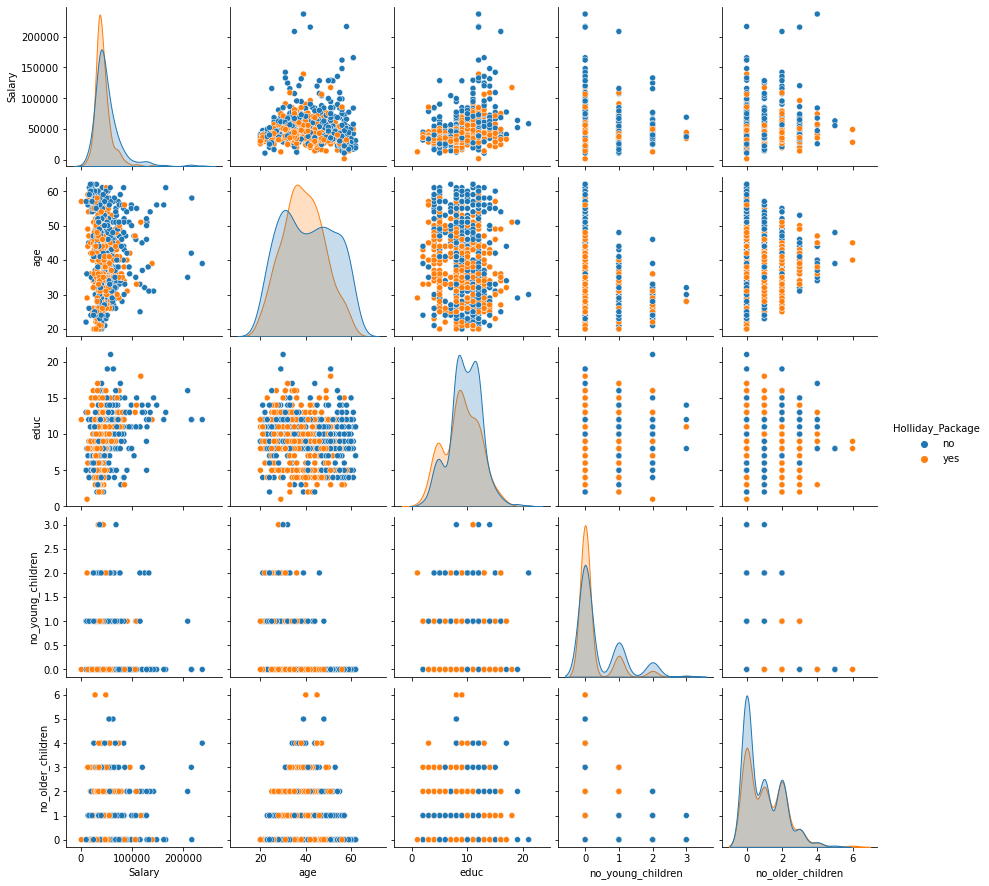

In [13]:
sns.pairplot(holiday,hue="Holliday_Package",diag_kind="kde")

In [14]:
holiday.corr()

,Salary,age,educ,no_young_children,no_older_children
Salary,1.000000,0.071709,0.326540,-0.029664,0.113772
age,0.071709,1.000000,-0.149294,-0.519093,-0.116205
educ,0.326540,-0.149294,1.000000,0.098350,-0.036321
no_young_children,-0.029664,-0.519093,0.098350,1.000000,-0.238428
no_older_children,0.113772,-0.116205,-0.036321,-0.238428,1.000000


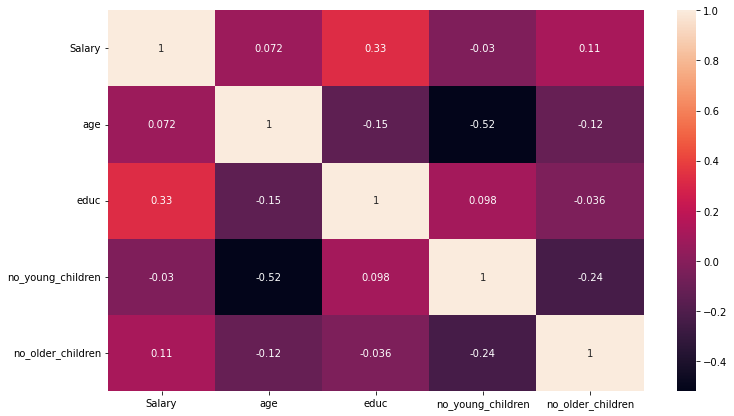

In [15]:
plt.figure(figsize=(12,7))
sns.heatmap(holiday.corr(),annot=True);

Text(0.5, 1.0, 'With outlier')

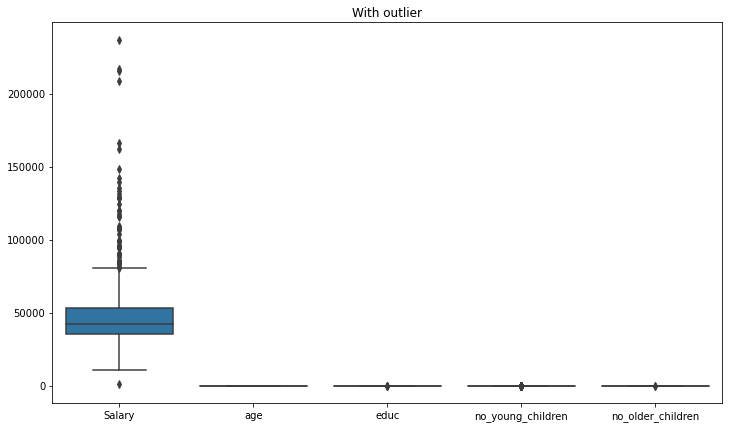

In [16]:
plt.figure(figsize=(12,7))
sns.boxplot(data=holiday)
plt.title("With outlier")

In [17]:
holiday["Holliday_Package"].value_counts()

no     471
yes    401
Name: Holliday_Package, dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
#we are applying label encoding on holliday package and foreign
LE=LabelEncoder()

In [17]:
holiday["Holliday_Package"]=LE.fit_transform(holiday["Holliday_Package"])

In [18]:
# no = 0 and yes = 1 for holliday package
holiday.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,no
1,1,37207,45,8,0,1,no
2,0,58022,46,9,0,0,no
3,0,66503,31,11,2,0,no
4,0,66734,44,12,0,2,no


In [19]:
holiday["foreign"]=LE.fit_transform(holiday["foreign"])

In [20]:
#no = 0 and yes = 1 for foreigners 
holiday.head()

,Holliday_Package,Salary,age,educ,no_young_children,no_older_children,foreign
0,0,48412,30,8,1,1,0
1,1,37207,45,8,0,1,0
2,0,58022,46,9,0,0,0
3,0,66503,31,11,2,0,0
4,0,66734,44,12,0,2,0


In [21]:
holiday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 872 entries, 0 to 871
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Holliday_Package   872 non-null    int32
 1   Salary             872 non-null    int64
 2   age                872 non-null    int64
 3   educ               872 non-null    int64
 4   no_young_children  872 non-null    int64
 5   no_older_children  872 non-null    int64
 6   foreign            872 non-null    int32
dtypes: int32(2), int64(5)
memory usage: 41.0 KB


In [22]:
x=holiday.drop("Holliday_Package",axis=1)
y=holiday['Holliday_Package']

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)

In [24]:
y_train.value_counts(1)

0    0.534426
1    0.465574
Name: Holliday_Package, dtype: float64

In [25]:
y_test.value_counts(1)

0    0.553435
1    0.446565
Name: Holliday_Package, dtype: float64

In [26]:
from sklearn.linear_model import LogisticRegression

# LOGISTIC REGRESSION

In [33]:
model=LogisticRegression(max_iter=10000,n_jobs=2)
model.fit(x_train,y_train)

LogisticRegression(max_iter=10000, n_jobs=2)

In [34]:
ytrain_predict=model.predict(x_train)
ytest_predict=model.predict(x_test)

In [35]:
ytest_predict_prob=model.predict_proba(x_test)

# Training set

In [36]:
#accuracy score
model.score(x_train,y_train)

0.519672131147541

In [37]:
from sklearn.metrics import roc_auc_score, roc_curve,classification_report, confusion_matrix,plot_confusion_matrix

AUC:0.567


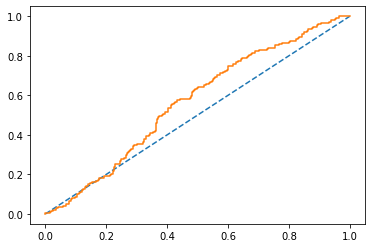

In [38]:
#auc_roc
probs=model.predict_proba(x_train)
probs=probs[:,1]
auc=roc_auc_score(y_train,probs)
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.53      0.90      0.67       326
           1       0.42      0.08      0.14       284

    accuracy                           0.52       610
   macro avg       0.47      0.49      0.40       610
weighted avg       0.48      0.52      0.42       610



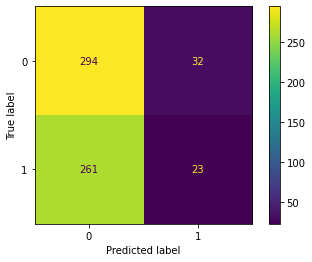

In [39]:
# confusion matrix and classification report
plot_confusion_matrix(model,x_train,y_train)
print(classification_report(y_train,ytrain_predict));


# Testing set

In [40]:
model.score(x_test,y_test)

0.5305343511450382

AUC:0.627


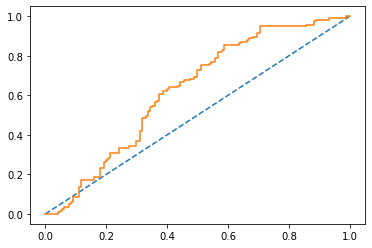

In [41]:
#auc_roc
probs=model.predict_proba(x_test)
probs=probs[:,1]
auc=roc_auc_score(y_test,probs)
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,probs)
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.55      0.89      0.68       145
           1       0.38      0.09      0.14       117

    accuracy                           0.53       262
   macro avg       0.47      0.49      0.41       262
weighted avg       0.47      0.53      0.44       262
 



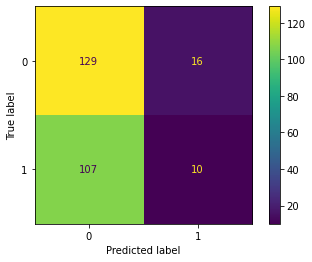

In [42]:
# confusion matrix and classification report
plot_confusion_matrix(model,x_test,y_test);
print(classification_report(y_test,ytest_predict),'\n');

# LDA

In [27]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [28]:
y_train.value_counts(normalize=True)

0    0.534426
1    0.465574
Name: Holliday_Package, dtype: float64

In [29]:
y_test.value_counts(normalize=True)

0    0.553435
1    0.446565
Name: Holliday_Package, dtype: float64

In [30]:

clf=LinearDiscriminantAnalysis()

In [31]:
model=clf.fit(x_train,y_train)

In [32]:
pred_class_train=model.predict(x_train)
pred_class_test=model.predict(x_test)

# Training set

In [33]:
#accuracy score
model.score(x_train,y_train)

0.6721311475409836

In [34]:
pred_prob_train=model.predict_proba(x_train)
pred_prob_test=model.predict_proba(x_test)

AUC:0.742


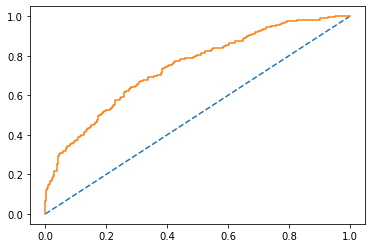

In [38]:
#auc_roc

auc=roc_auc_score(y_train,pred_prob_train[:,1])
print("AUC:%.3f"%auc)
train_fpr,train_tpr,train_thresholds=roc_curve(y_train,pred_prob_train[:,1])
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(train_fpr,train_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.67      0.77      0.72       326
           1       0.68      0.56      0.61       284

    accuracy                           0.67       610
   macro avg       0.67      0.66      0.66       610
weighted avg       0.67      0.67      0.67       610
 



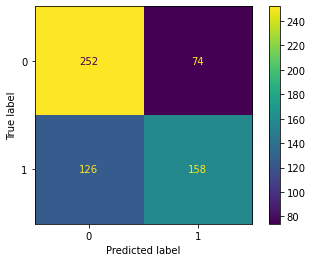

In [39]:
plot_confusion_matrix(model,x_train,y_train);
print(classification_report(y_train,pred_class_train),'\n');

# Testing set

In [40]:
#accuracy score
model.score(x_test,y_test)

0.6412213740458015

AUC:0.703


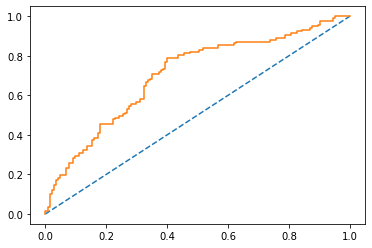

In [41]:
#auc roc
auc=roc_auc_score(y_test,pred_prob_test[:,1])
print("AUC:%.3f"%auc)
test_fpr,test_tpr,test_thresholds=roc_curve(y_test,pred_prob_test[:,1])
plt.plot([0,1],[0,1],linestyle="--")
plt.plot(test_fpr,test_tpr);

C:\Users\LENOVO\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


              precision    recall  f1-score   support

           0       0.66      0.71      0.69       145
           1       0.61      0.56      0.58       117

    accuracy                           0.64       262
   macro avg       0.64      0.63      0.63       262
weighted avg       0.64      0.64      0.64       262
 



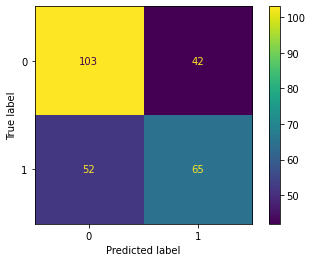

In [42]:
plot_confusion_matrix(model,x_test,y_test);
print(classification_report(y_test,pred_class_test),'\n');